In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor

In [2]:
#  When p = 1, this is equivalent to using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.

In [3]:
df= sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [28]:
df.species.value_counts()

from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
df['species']= le.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


<Axes: xlabel='petal_length', ylabel='petal_width'>

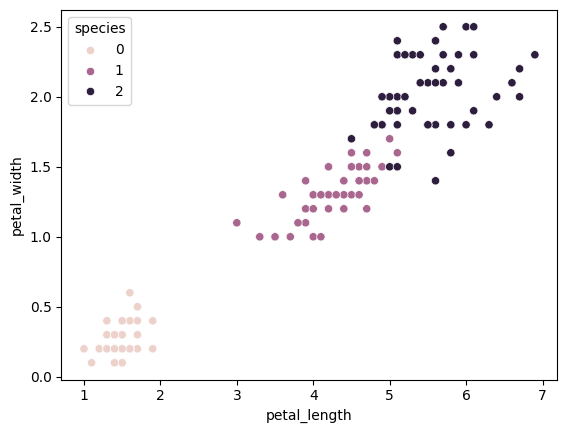

In [29]:
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')

In [30]:
knn= KNeighborsClassifier(n_neighbors=3,p=2)

In [31]:
# independent and dependent variables

x= df.drop('species', axis=1)
y= df['species']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.3, random_state=20)


In [32]:
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [33]:
y_pred= knn.predict(x_test)

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [35]:
confusion_matrix(y_test,y_pred)

array([[13,  0,  0],
       [ 0, 17,  1],
       [ 0,  2, 12]])

In [36]:
accuracy_score(y_test,y_pred)

0.9333333333333333

In [37]:
import joblib

In [38]:
joblib.dump(knn,'iris.pkl')

['iris.pkl']

In [39]:
model= joblib.load('iris.pkl')

In [40]:
data=[4.7,3.2,1.3,0.2]

In [44]:
result= model.predict([data])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [45]:
result

array([0])

In [43]:
classes= le.classes_

In [46]:
classes[result[0]]

'setosa'